In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tensorflow as tf

In [2]:
import os

DATASET_DIRECTORY = './flowers'
root = os.path.join(os.getcwd(), DATASET_DIRECTORY)

classes = np.array(os.listdir(root))
classes

array(['daisy', 'dandelion', 'rose', 'sunflower', 'tulip'], dtype='<U9')

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    root, subset="training", seed=47,
    label_mode="int", validation_split=0.2,
    image_size=(128, 128), batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    root, subset="validation", seed=47,
    label_mode="int", validation_split=0.2,
    image_size=(128, 128), batch_size=32
)

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.


In [4]:
train_ds = train_ds.map(lambda X,y: (X / 255.0, y) )
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

x_train = np.concatenate([x for x, y in train_ds], axis=0)
y_train = np.concatenate([y for x, y in train_ds], axis=0)

test_ds = train_ds.map(lambda X,y: (X / 255.0, y) )
test_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

x_test = np.concatenate([x for x, y in test_ds], axis=0)
y_test = np.concatenate([y for x, y in test_ds], axis=0)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((3454, 128, 128, 3), (3454,), (3454, 128, 128, 3), (3454,))

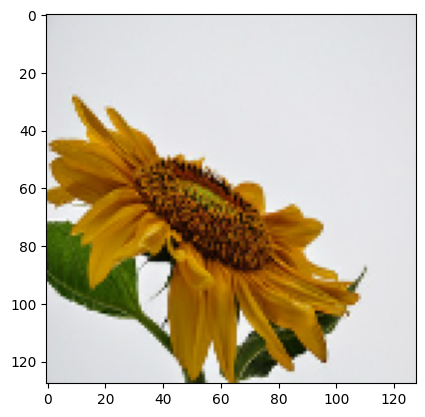

In [5]:
image = x_train[4]

plt.imshow(image)
plt.show()

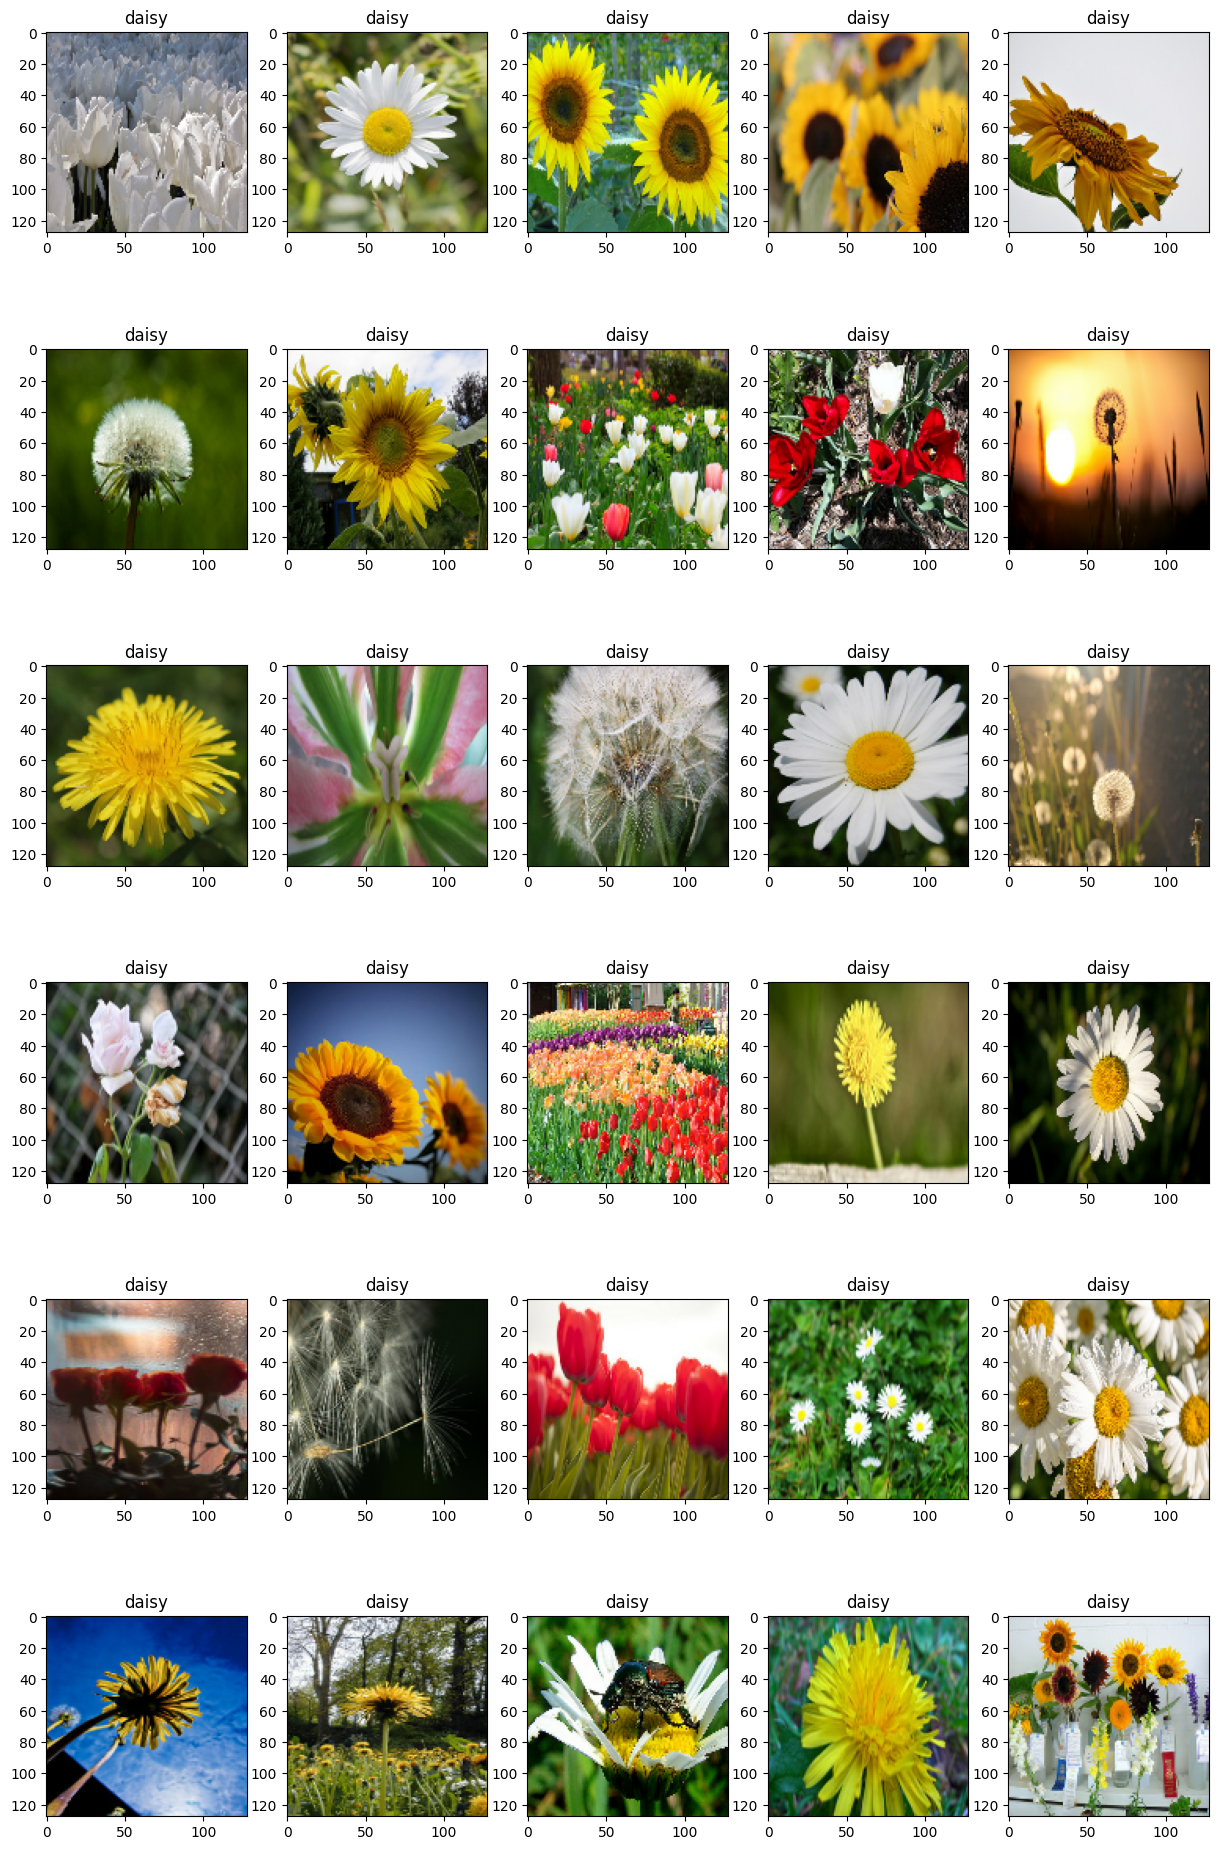

In [6]:
rows = 6
cols = 5

plt.figure( figsize=(15,24)  )
for index in range(rows * cols):
    plt.subplot(rows, cols, index + 1)
    plt.imshow(x_train[index])
    plt.title( classes[ np.argmax(y_train[index]) ])

plt.show()

In [7]:
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D

cnn_model = Sequential([
    Input(shape=(128, 128, 3), name="Input"),
    Conv2D(32, (3, 3), activation="relu", name="Convolution_2D" ),
    
    MaxPooling2D((5, 5), name="Max_Pooling"),
    Flatten(name="Flatting"),
    
    Dense(128, activation="relu", name="Hidden_1"),
    Dense(5, activation="softmax", name="Output")
], name="Flower_Classification")
cnn_model.summary()

Model: "Flower_Classification"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Convolution_2D (Conv2D)              │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Max_Pooling (MaxPooling2D)           │ (None, 25, 25, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Flatting (Flatten)                   │ (None, 20000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_1 (Dense)                     │ (None, 128)                 │       2,560,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output (Dense)                       │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,561,669 (9.77 MB)

 Trainable params: 2,561,669 (9.77 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.optimizers import SGD
optimizer = SGD(learning_rate=0.01)

cnn_model.compile(
    optimizer= optimizer, metrics=['accuracy'],
    loss= tf.keras.losses.SparseCategoricalCrossentropy
)

history = cnn_model.fit(x_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - accuracy: 0.3380 - loss: 1.4754 - val_accuracy: 0.4428 - val_loss: 1.3087
Epoch 2/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 20s 123ms/step - accuracy: 0.4473 - loss: 1.2984 - val_accuracy: 0.3705 - val_loss: 1.3116
Epoch 3/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.4944 - loss: 1.1938 - val_accuracy: 0.4559 - val_loss: 1.2005
Epoch 4/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.5353 - loss: 1.1228 - val_accuracy: 0.5326 - val_loss: 1.1100
Epoch 5/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.5610 - loss: 1.0630 - val_accuracy: 0.5427 - val_loss: 1.1059


In [9]:
test_loss, test_accuracy = cnn_model.evaluate(x_test, y_test)

test_indices = np.array([47, 232, 453, 1000])
index = cnn_model.predict(x_train[ test_indices ])

print(f"Actual Classes Are {classes[ y_train[test_indices] ]}")
print(f"Predicted Classes Are {classes[ [ np.argmax(i) for i in index ] ]}")

108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5761 - loss: 1.0588
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
Actual Classes Are ['rose' 'daisy' 'tulip' 'dandelion']
Predicted Classes Are ['tulip' 'dandelion' 'rose' 'daisy']


In [10]:
training_loss = history.history['loss'][-1]
training_accuracy = history.history['accuracy'][-1]

metrics = pd.DataFrame(
    data= [ [training_loss, training_accuracy], [test_loss, test_accuracy] ],
columns=["Loss", "Accuracy"], index=["Training", "Testing"] )
metrics

cnn_metrics = metrics

In [11]:
ann_model = Sequential([
    Input(shape=(128, 128, 3), name="Input"),
    Flatten(name="Flatting"),
    
    Dense(128, activation="relu", name="Hidden_1"),
    Dense(5, activation="softmax", name="Output")
], name="Flower_Classification")
ann_model.summary()

Model: "Flower_Classification"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Flatting (Flatten)                   │ (None, 49152)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_1 (Dense)                     │ (None, 128)                 │       6,291,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output (Dense)                       │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,292,229 (24.00 MB)

 Trainable params: 6,292,229 (24.00 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
optimizer = SGD(learning_rate=0.01)

history = ann_model.compile(
    optimizer= optimizer, metrics=['accuracy'],
    loss= tf.keras.losses.SparseCategoricalCrossentropy
)

history = ann_model.fit(x_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.3022 - loss: 1.5941 - val_accuracy: 0.1939 - val_loss: 2.0174
Epoch 2/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.3923 - loss: 1.3912 - val_accuracy: 0.3575 - val_loss: 1.4357
Epoch 3/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.4260 - loss: 1.3086 - val_accuracy: 0.3748 - val_loss: 1.3511
Epoch 4/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.4466 - loss: 1.2513 - val_accuracy: 0.4255 - val_loss: 1.2411
Epoch 5/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.4506 - loss: 1.2461 - val_accuracy: 0.3965 - val_loss: 1.4780


In [13]:
test_loss, test_accuracy = ann_model.evaluate(x_test, y_test)

test_indices = np.array([47, 232, 453, 1000])
index = cnn_model.predict(x_train[ test_indices ])

print(f"Actual Classes Are {classes[ y_train[test_indices] ]}")
print(f"Predicted Classes Are {classes[ [ np.argmax(i) for i in index ] ]}")

108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3975 - loss: 1.4275
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Actual Classes Are ['rose' 'daisy' 'tulip' 'dandelion']
Predicted Classes Are ['tulip' 'dandelion' 'rose' 'daisy']


In [14]:
training_loss = history.history['loss'][-1]
training_accuracy = history.history['accuracy'][-1]

metrics = pd.DataFrame(
    data= [ [training_loss, training_accuracy], [test_loss, test_accuracy] ],
columns=["Loss", "Accuracy"], index=["Training", "Testing"] )
metrics

ann_metrics = metrics

In [15]:
cnn_metrics

,Loss,Accuracy
Training,1.063014,0.560984
Testing,1.058762,0.576144


In [16]:
ann_metrics

,Loss,Accuracy
Training,1.246127,0.450597
Testing,1.427489,0.397510
